# Teste de treinamento de modelo para predição de Resistência utilizando CatBoost

In [1]:
%%capture
!pip install catboost ipywidgets optuna shapS

In [3]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GroupKFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, shap
import seaborn as sns
import pandas as pd
import numpy as np

### Montagem do drive

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_CatBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 586 entries, 3 to 598
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Finura_Cimento_Blaine_m2_kg     586 non-null    float64
 1   Agua_kg_m3                      586 non-null    float64
 2   Superplastificante_kg_m3        586 non-null    float64
 3   Relacao_Agua_Cimento            586 non-null    float64
 4   Tipo_Molde_Cod                  586 non-null    int64  
 5   Metodo_Emp_Cod                  586 non-null    int64  
 6   Usa_SP                          586 non-null    bool   
 7   Classe_Cim_OpA                  586 non-null    int64  
 8   Relacao_Agua_Aglomerante        586 non-null    float64
 9   Filer_D50_um                    586 non-null    float64
 10  D_Max                           586 non-null    float64
 11  cod_classe                      586 non-null    int64  
 12  Cluster_ID                      586 non-n

In [6]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 18


In [7]:
hyper_params = {
    'iterations': 800,             # Equivalente ao n_estimators.
    'learning_rate': 0.05,
    'depth': 2,                    # Mantendo nossa "fortaleza" intocável
    'l2_leaf_reg': 10,             # Regularização pesada (equivalente ao reg_lambda)
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    # O Sistema anti-overfitting do CatBoost
    'od_type': 'Iter',             # Ativa o detector de overfitting (Overfitting Detector)
    'od_wait': 50                  # Se a validação não melhorar por 50 iterações, ele interrompe a busca
}

In [8]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []

results = []
importancias_cat = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(**hyper_params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
        verbose=False
    )

    preds = model.predict(X_val)

    # histórico de métricas
    eval_results = model.get_evals_result()

    results.append(eval_results)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

    importancias_cat.append(model.feature_importances_)

CPU times: user 5.3 s, sys: 323 ms, total: 5.62 s
Wall time: 4.06 s


In [14]:
results[0]['learn'].keys()

dict_keys(['RMSE'])

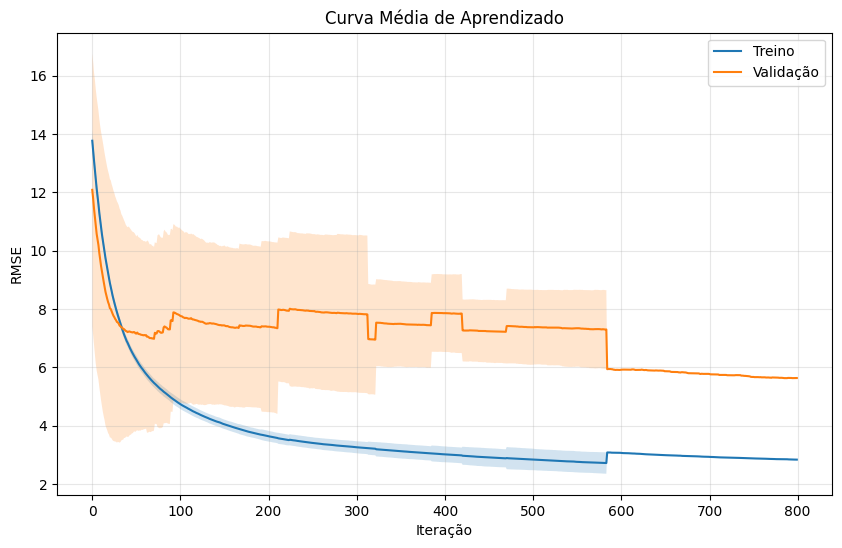

In [20]:
train_curves = []
val_curves = []

for evals_result in results:

    train_curves.append(
        evals_result['learn']['RMSE']
    )

    val_curves.append(
        evals_result['validation']['RMSE']
    )

max_len = max(len(c) for c in train_curves)

train_matrix = np.full(
    (len(train_curves), max_len),
    np.nan
)

val_matrix = np.full(
    (len(val_curves), max_len),
    np.nan
)

for i, curve in enumerate(train_curves):
    train_matrix[i, :len(curve)] = curve

for i, curve in enumerate(val_curves):
    val_matrix[i, :len(curve)] = curve

train_mean = np.nanmean(train_matrix, axis=0)
train_std = np.nanstd(train_matrix, axis=0)

val_mean = np.nanmean(val_matrix, axis=0)
val_std = np.nanstd(val_matrix, axis=0)

iterations = np.arange(max_len)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_mean, label='Treino')
plt.plot(iterations, val_mean, label='Validação')

plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Iteração')
plt.ylabel('RMSE')

plt.title('Curva Média de Aprendizado')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [22]:
# Estatísticas finais
val_final = val_mean[-1]
train_final = train_mean[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      2.834904
⚠️  RMSE Validação (final):   5.632519
📈 Gap (Val - Train):        2.797615


In [33]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true).ravel(),
    'y_pred': np.array(all_preds).ravel(),
    'group': np.array(all_groups).ravel()
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']

)

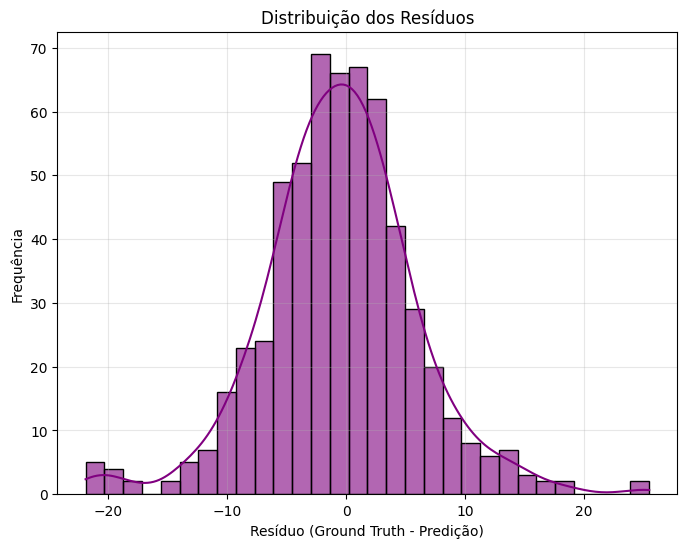

In [34]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

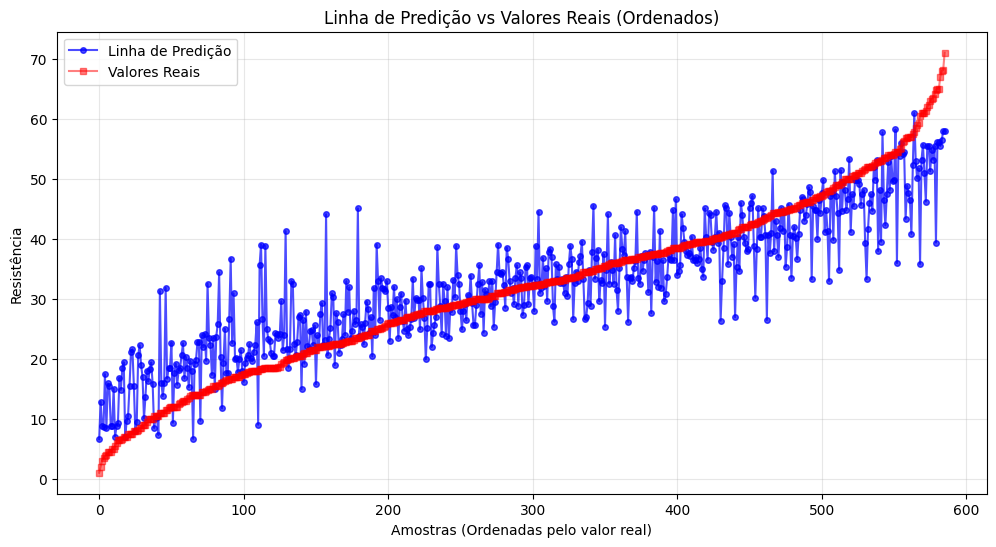

In [35]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.4147
mean_absolute_error: 4.7895
mean_absolute_percentage_error: 0.2479
R² Score: 79.5747


In [37]:
model_path = os.path.join(dirpath, "melhor_modelo_resistencia_CatBoost.json")
model.save_model(model_path)
print(f"✅ Modelo salvo em: {model_path}")
print(f"\n📋 Informações do Modelo:")
print(f"  • Número de boosting rounds: {model.get_num_boosting_rounds()}")

✅ Modelo salvo em: /content/drive/MyDrive/supervised-learning-studies/projeto/resistencia/melhor_modelo_resistencia_CatBoost.json

📋 Informações do Modelo:


AttributeError: 'CatBoostRegressor' object has no attribute 'get_num_boosting_rounds'

/tmp/ipykernel_12063/4065326967.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


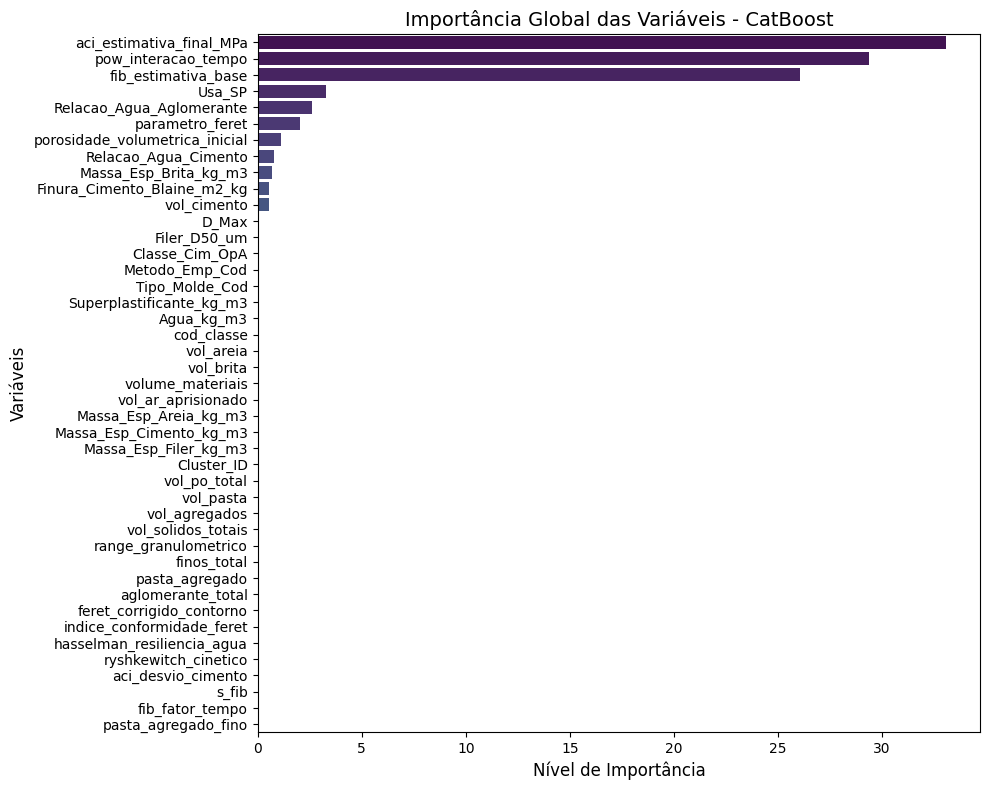

In [38]:
importancias = model.get_feature_importance()
features = X_train.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()